In [11]:
import pandas as pd
import numpy as np

cols = ["age","workclass","fnlwgt","education","education_num",
        "marital_status","occupation","relationship","race","sex",
        "capital_gain","capital_loss","hours_per_week",
        "native_country","income"]

df = pd.read_csv("adult.csv", names=cols, skipinitialspace=True)
df = df.replace("?", np.nan)

print(df.shape)
print(df.head())
print(df["income"].value_counts())
print(df.isna().sum())

(32561, 15)
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0 

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (26048, 14)
Test: (6513, 14)


In [13]:
from sklearn.impute import KNNImputer

col = "hours_per_week"

drop_data = X_train.dropna(subset=[col])

mean_data = X_train.copy()
mean_data[col] = mean_data[col].fillna(mean_data[col].mean())

knn = KNNImputer(n_neighbors=5)
knn_data = X_train.copy()
knn_data[[col]] = knn.fit_transform(knn_data[[col]])

print("Drop:", drop_data[col].mean(), drop_data[col].std())
print("Mean:", mean_data[col].mean(), mean_data[col].std())
print("KNN:", knn_data[col].mean(), knn_data[col].std())

Drop: 40.48072788697789 12.417613205670746
Mean: 40.48072788697789 12.417613205670746
KNN: 40.48072788697789 12.417613205670746


In [14]:
from scipy.stats import zscore

x = X_train["capital_gain"].dropna()

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

iqr = (x < Q1 - 1.5 * IQR) | (x > Q3 + 1.5 * IQR)
z = abs(zscore(x)) > 3

low = x.quantile(0.01)
high = x.quantile(0.99)
capped = (x < low) | (x > high)

print("IQR:", iqr.sum())
print("Z-score:", z.sum())
print("1%-99%:", capped.sum())
print("IQR & Z-score overlap:", (iqr & z).sum())
print("IQR & percentile overlap:", (iqr & capped).sum())
print("Z-score & percentile overlap:", (z & capped).sum())

IQR: 2149
Z-score: 164
1%-99%: 201
IQR & Z-score overlap: 164
IQR & percentile overlap: 201
Z-score & percentile overlap: 164


In [15]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

onehot = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
a = onehot.fit_transform(X_train[["sex"]])

order = [["Preschool","1st-4th","5th-6th","7th-8th","9th","10th",
          "11th","12th","HS-grad","Some-college","Assoc-voc",
          "Assoc-acdm","Bachelors","Masters","Prof-school","Doctorate"]]

ordinal = OrdinalEncoder(categories=order)
b = ordinal.fit_transform(X_train[["education"]])

freq = X_train["occupation"].value_counts(normalize=True)
c = X_train["occupation"].map(freq)

print("One-hot columns:", a.shape[1])
print("Ordinal columns:", b.shape[1])
print("Frequency encoded length:", c.shape[0])

One-hot columns: 2
Ordinal columns: 1
Frequency encoded length: 26048


In [16]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train[["workclass"]])

test = pd.DataFrame({"workclass": ["Never-seen-before"]})

result = encoder.transform(test)

print("Encoded successfully:", result.shape)

Encoded successfully: (1, 9)


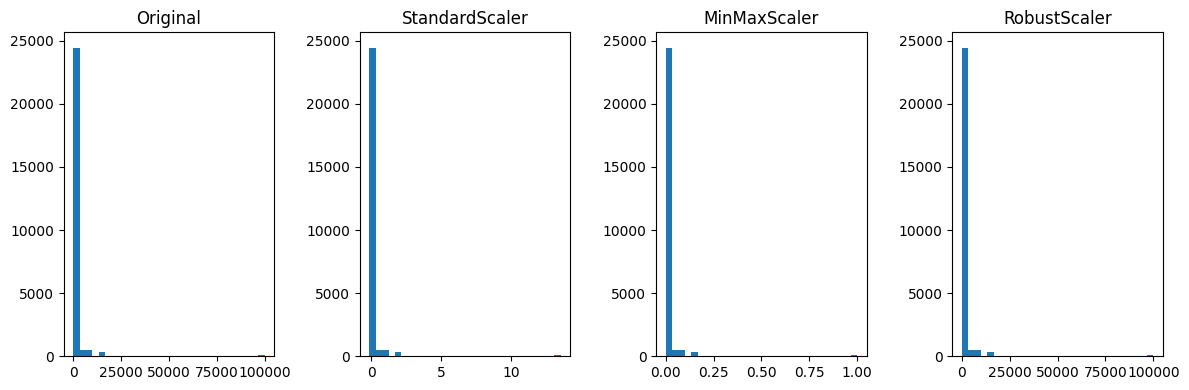

In [17]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

x = X_train[["capital_gain"]].fillna(X_train["capital_gain"].median())

standard = StandardScaler().fit_transform(x)
minimum = MinMaxScaler().fit_transform(x)
robust = RobustScaler().fit_transform(x)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.hist(x["capital_gain"], bins=30)
plt.title("Original")

plt.subplot(1, 4, 2)
plt.hist(standard, bins=30)
plt.title("StandardScaler")

plt.subplot(1, 4, 3)
plt.hist(minimum, bins=30)
plt.title("MinMaxScaler")

plt.subplot(1, 4, 4)
plt.hist(robust, bins=30)
plt.title("RobustScaler")

plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import PowerTransformer

x = X_train[["capital_gain"]].fillna(0)

log_x = np.log1p(x)

yj = PowerTransformer(method="yeo-johnson")
yj_x = yj.fit_transform(x)

print("Original skewness:", x["capital_gain"].skew())
print("Log1p skewness:", log_x["capital_gain"].skew())
print("Yeo-Johnson skewness:", pd.Series(yj_x.flatten()).skew())

Original skewness: 12.080436198279514
Log1p skewness: 3.1142950305515837
Yeo-Johnson skewness: 3.0351223577781297


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
cat_cols = ["workclass", "education", "marital_status", "occupation", "relationship", "race", "sex"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor)
])

pipeline.fit(X_train, y_train)

X_train_ready = pipeline.transform(X_train)
X_test_ready = pipeline.transform(X_test)

print("Train shape:", X_train_ready.shape)
print("Test shape:", X_test_ready.shape)

Train shape: (26048, 63)
Test shape: (6513, 63)


In [20]:
from sklearn.preprocessing import StandardScaler

col = "capital_gain"

full_scaler = StandardScaler()
full_scaled = full_scaler.fit_transform(df[[col]].fillna(0))

train_scaler = StandardScaler()
train_scaler.fit(X_train[[col]].fillna(0))
correct_scaled = train_scaler.transform(X_test[[col]].fillna(0))

leaky_values = full_scaled[X_test.index][:5].flatten()
correct_values = correct_scaled[:5].flatten()

print("Leaky values:", leaky_values)
print("Correct values:", correct_values)
print("Difference:", leaky_values - correct_values)

Leaky values: [-0.14592048 -0.14592048  1.1250034  -0.14592048 -0.14592048]
Correct values: [-0.14531872 -0.14531872  1.14060916 -0.14531872 -0.14531872]
Difference: [-0.00060176 -0.00060176 -0.01560575 -0.00060176 -0.00060176]


In [21]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

print("\nClass ratio:")
print(y_train.value_counts(normalize=True))

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train.select_dtypes(include=np.number),
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
income
<=50K    19775
>50K      6273
Name: count, dtype: int64

Class ratio:
income
<=50K    0.759175
>50K     0.240825
Name: proportion, dtype: float64

After SMOTE:
income
>50K     19775
<=50K    19775
Name: count, dtype: int64


In [22]:
import joblib

joblib.dump(pipeline, "pipeline.joblib")

loaded_pipeline = joblib.load("pipeline.joblib")

new_row = X_test.iloc[[0]]
result = loaded_pipeline.transform
print("Original row shape:", new_row.shape)
print("Transformed row shape:", result.shape)

Original row shape: (1, 14)
Transformed row shape: (1, 63)


question 12

Q2:KNNImputer because it looks at nearby values to fill the missing data instead of just using one fixed value.

Q3: I chose the IQR method because it works better when the data has extreme values.

Q6: I chose RobustScaler because it is less affected by outliers , because its faster then StandardScaler